In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("train_cleaned.csv")

df.head()

C:\Users\sue\AppData\Local\Temp\ipykernel_45612\35942054.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train_cleaned.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
df.shape

(1017209, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [5]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

# Overall EDA Findings

The exploratory data analysis identified several important patterns in the Rossmann sales data.

- Sales are strongly right-skewed, with many observations at lower sales values and a smaller number of very high sales.
- Customer numbers show the strongest positive relationship with sales. The correlation between Customers and Sales is approximately 0.89.
- Promotions are associated with higher sales, suggesting that promotional activities can improve store performance.
- Store opening status has a major effect on sales. Closed stores record zero sales, while open stores generate substantially higher sales.
- Sales vary across different days of the week. Day 1 has the highest average sales, while Day 7 has the lowest.
- The correlation analysis also shows that DayOfWeek has a moderate negative relationship with Sales, while Promo and Open have positive relationships with Sales.

Overall, Customers, Promo, Open and DayOfWeek appear to be important variables for explaining and forecasting sales. These variables should be considered in the modelling stage.

## Data Overview

**Relationship**

The cleaned dataset contains 1,017,209 observations and 9 variables. No missing values were found, indicating the data cleaning process was successful.

**Insight**

The dataset is complete and suitable for exploratory data analysis and predictive modelling.

# Sales Distribution

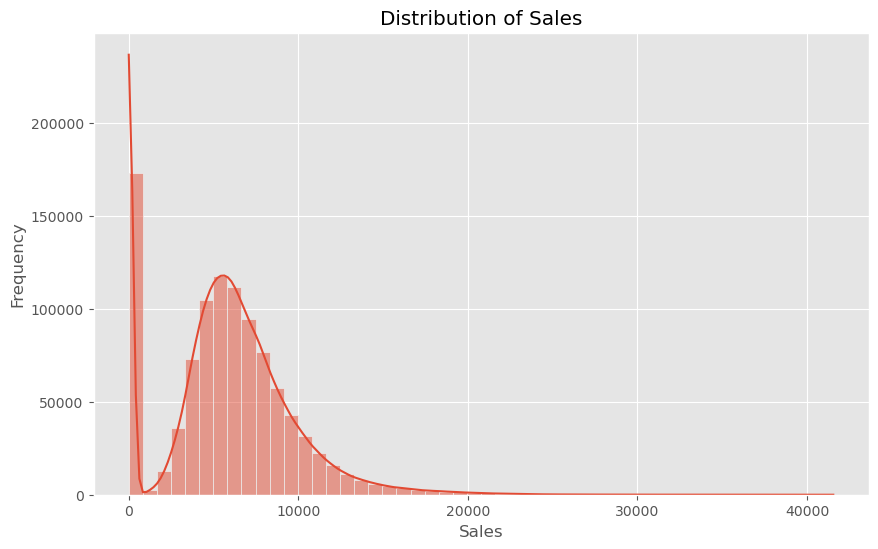

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(df["Sales"], bins=50, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Relationship

The distribution of sales is highly right-skewed. Most observations are concentrated at lower sales values, while a small number of observations have much higher sales.

### Insight

A large number of observations have sales close to zero, while most remaining sales fall between approximately 4,000 and 8,000. The long right tail indicates that only a small proportion of stores achieve exceptionally high sales, suggesting possible effects of promotions, customer traffic, or other store characteristics.

# Sales by Day of Week

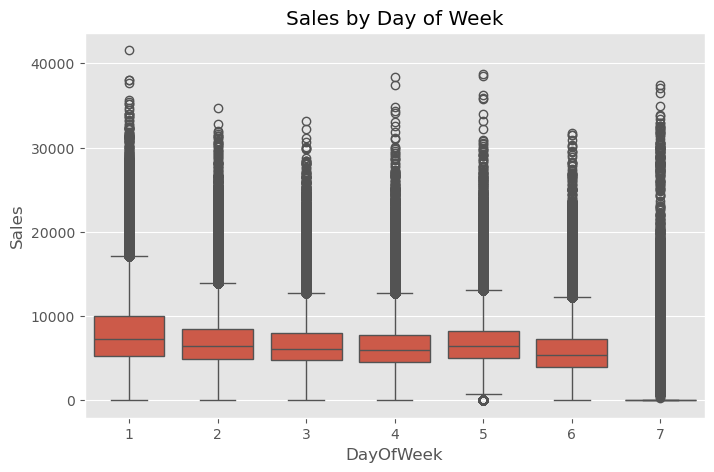

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="DayOfWeek",
    y="Sales"
)

plt.title("Sales by Day of Week")

plt.show()

### Relationship

Sales vary across different days of the week. The median sales and the spread of sales are different for each weekday, indicating that the day of the week influences sales performance.

### Insight

Days 1 and 5 generally have higher median sales than the other weekdays, while Day 7 contains many observations with zero sales, suggesting that many stores are closed or have very low sales on that day. In addition, every weekday contains several high-sales outliers, indicating that some stores consistently achieve much higher sales than the average.

# Promo vs Sales

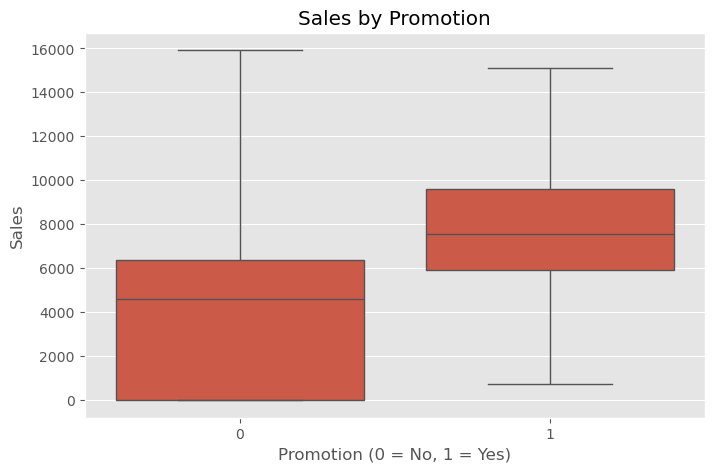

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Promo",
    y="Sales",
    showfliers=False
)

plt.title("Sales by Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Sales")

plt.show()

### Relationship

The boxplot compares sales between stores without promotions (Promo = 0) and stores with promotions (Promo = 1). Stores running promotions generally have higher sales than those without promotions.

### Insight

The median sales for stores with promotions are much higher than for stores without promotions. This indicates that promotional activities have a positive impact on sales and are likely to attract more customers.

# Customers vs Sales

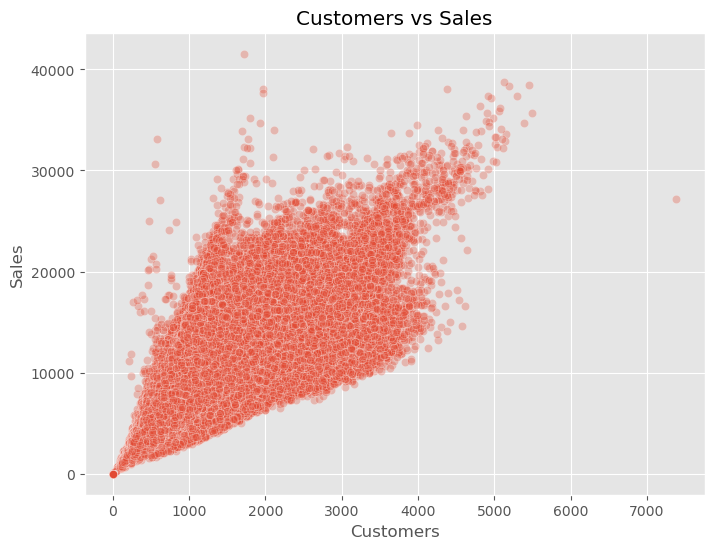

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Customers",
    y="Sales",
    alpha=0.3
)

plt.title("Customers vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.show()

### Relationship

The scatter plot shows a strong positive relationship between the number of customers and sales. As the number of customers increases, sales also tend to increase.

### Insight

Stores with more customers generally achieve higher sales. This suggests that customer traffic is an important factor influencing sales and should be considered in forecasting models.

# Correlation Heatmap



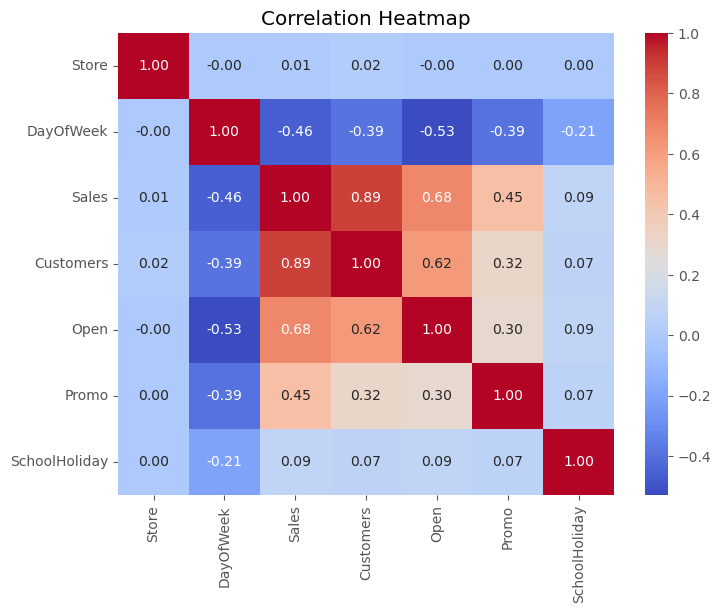

In [14]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Relationship

The heatmap shows the correlations between the numerical variables. Sales has a strong positive correlation with Customers (0.89) and a moderate positive correlation with Open (0.68) and Promo (0.45). DayOfWeek has a moderate negative correlation with Sales (-0.46).

### Insight

Customers is the variable most strongly associated with Sales, suggesting that stores with more customers generally achieve higher sales. Open and Promo also have positive relationships with Sales, while sales tend to vary across different days of the week. These variables are likely to be useful predictors in the forecasting model.

# Sales by Store Status



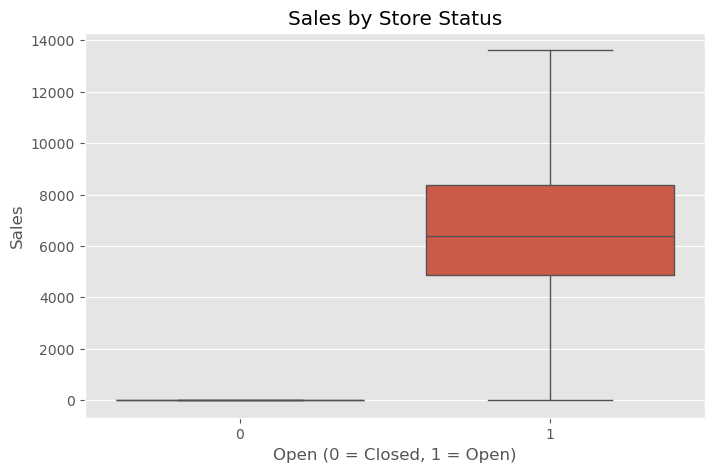

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Open",
    y="Sales",
    showfliers=False
)

plt.title("Sales by Store Status")
plt.xlabel("Open (0 = Closed, 1 = Open)")
plt.ylabel("Sales")

plt.show()

### Relationship

Sales differ greatly between closed and open stores. Closed stores have sales of zero, while open stores show much higher sales values.

### Insight

Store opening status has a major impact on sales. When stores are closed, sales are zero, while open stores typically generate sales between approximately 5,000 and 8,000. This confirms that the `Open` variable is an important factor for sales forecasting.

# Average Sales by Day of Week


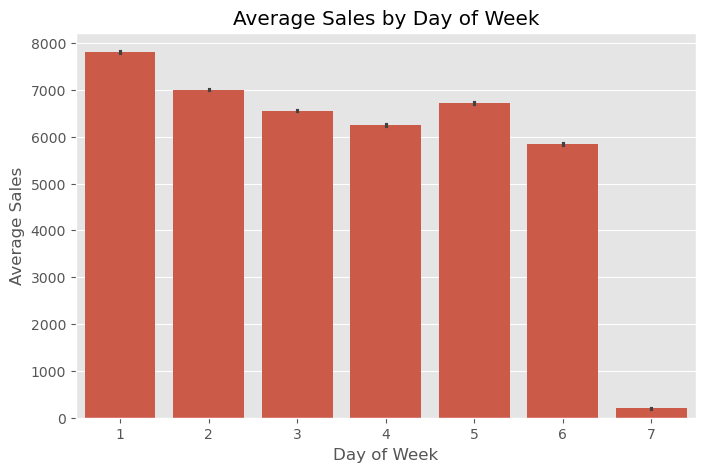

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="DayOfWeek",
    y="Sales",
    estimator="mean"
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.show()


### Relationship

Average sales vary considerably across different days of the week. Day 1 has the highest average sales, while Day 7 has by far the lowest average sales.

### Insight

Sales generally decline from Day 1 to Day 4, increase slightly on Day 5, and then decrease again on Day 6. Day 7 has extremely low average sales compared with all other days, which is likely related to many stores being closed. This shows that day of the week is an important factor to consider when forecasting sales.